## 🔧 Setup: Import All Required Libraries

We import everything needed once here so all practicals can run independently.

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Datasets ─────────────────────────────────────────────────────────────────
from sklearn.datasets import (
    load_iris, load_breast_cancer, load_wine,
    load_digits, make_regression, make_classification,
    make_moons, make_blobs
)

# ─── Preprocessing ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PolynomialFeatures, LabelEncoder
)

# ─── Classification Models ────────────────────────────────────────────────────
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression, Lasso, Ridge, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier, MLPRegressor

# ─── Clustering ───────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    # Classification
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score,
    # Regression
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.pipeline import Pipeline

# ─── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
})
COLORS = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
# 🔬 Practical 1: Naïve Bayes Classifier




In [2]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 1: NAÏVE BAYES CLASSIFIER
# Dataset: Iris (150 samples, 4 features, 3 classes)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Load Dataset ────────────────────────────────────────────
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names   = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df['Species'] = [class_names[i] for i in y]
print("Dataset Shape:", X.shape)
print("Classes:", class_names)
print("\nFirst 5 rows:")
display(df.head())
print("\nClass distribution:")
print(df['Species'].value_counts())

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Class distribution:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [3]:
# ── Step 2: Split into Train / Test (80-20) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ── Step 3: Build & Train GaussianNB ────────────────────────────────
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# ── Step 4: Predict ─────────────────────────────────────────────────
y_pred = gnb.predict(X_test)
y_prob = gnb.predict_proba(X_test)

# ── Step 5: Evaluation Metrics ──────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"\n{'='*50}")
print(f"  NAÏVE BAYES — EVALUATION RESULTS")
print(f"{'='*50}")
print(f"  Accuracy : {acc*100:.2f}%")
print(f"  Error    : {(1-acc)*100:.2f}%")
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# ── Step 6: k-Fold Cross Validation (k=5) ───────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(GaussianNB(), X, y, cv=kf, scoring='accuracy')
print(f"  5-Fold CV Scores : {cv_scores.round(3)}")
print(f"  Mean CV Accuracy : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

Train size: 120  |  Test size: 30

  NAÏVE BAYES — EVALUATION RESULTS
  Accuracy : 96.67%
  Error    : 3.33%

  Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

  5-Fold CV Scores : [1.    0.967 0.933 0.967 0.933]
  Mean CV Accuracy : 96.00% ± 2.49%


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\user-data\\outputs\\P1_NaiveBayes.png'

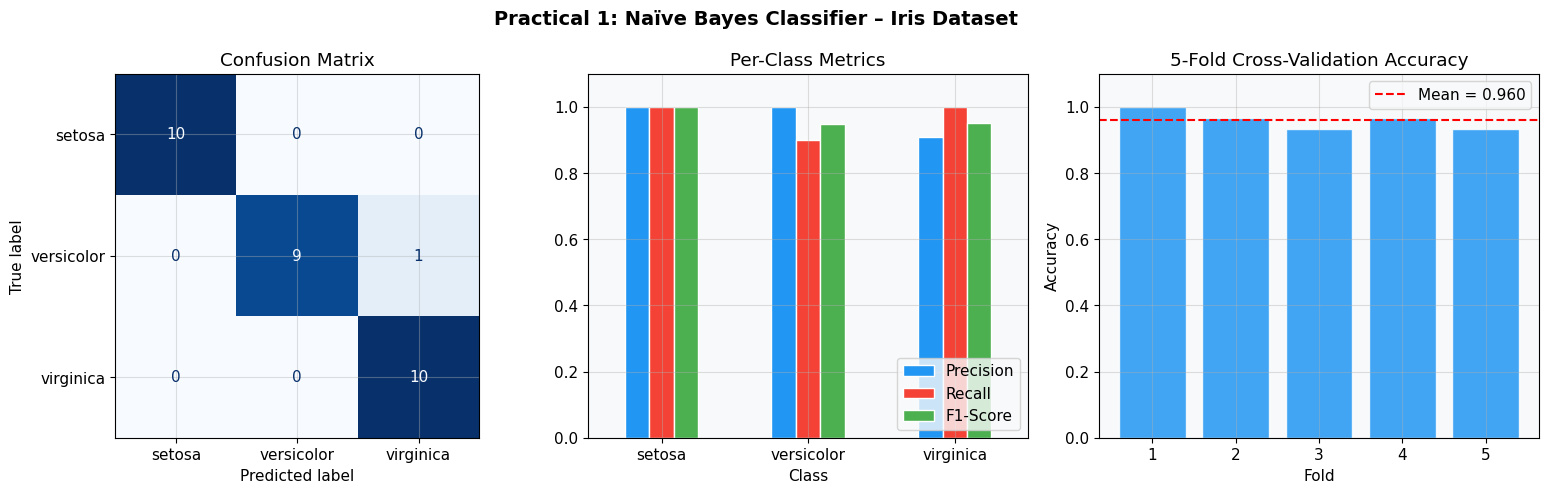

In [ ]:
# ── Step 7: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical 1: Naïve Bayes Classifier – Iris Dataset', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix')

# Compute per-class metrics from confusion matrix
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

# Plot 2: Per-class Metrics Bar Chart
metrics_df = pd.DataFrame({
    'Precision': precision_score(y_test, y_pred, average=None),
    'Recall':    recall_score(y_test, y_pred, average=None),
    'F1-Score':  f1_score(y_test, y_pred, average=None)
}, index=class_names)
metrics_df.plot(kind='bar', ax=axes[1], color=COLORS[:3], edgecolor='white')
axes[1].set_title('Per-Class Metrics')
axes[1].set_ylim(0, 1.1)
axes[1].set_xlabel('Class')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='lower right')

# Plot 3: Cross-Validation Scores
axes[2].bar(range(1, 6), cv_scores, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[2].axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
axes[2].set_title('5-Fold Cross-Validation Accuracy')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.1)
axes[2].legend()

plt.tight_layout()
plt.show()
print("\n✅ Practical 1 Complete!")

---
# 🔬 Practical 2: Simple Linear Regression


**Evaluation Metrics for Regression:**

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **MSE** | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | Lower is better; sensitive to outliers |
| **RMSE** | $\sqrt{MSE}$ | Same units as y; easier to interpret |
| **MAE** | $\frac{1}{n}\sum|y_i-\hat{y}_i|$ | Lower is better; robust to outliers |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Closer to 1 is better; proportion of variance explained |

In [5]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 2: SIMPLE LINEAR REGRESSION
# Synthetic dataset: Hours studied vs Exam score
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Create a realistic dataset ─────────────────────────────
np.random.seed(42)
hours_studied = np.linspace(1, 10, 100) + np.random.normal(0, 0.3, 100)
exam_score    = 45 + 5.2 * hours_studied + np.random.normal(0, 4, 100)
exam_score    = np.clip(exam_score, 0, 100)

df2 = pd.DataFrame({'Hours_Studied': hours_studied, 'Exam_Score': exam_score})
print("Dataset Summary:")
display(df2.describe())

X2 = hours_studied.reshape(-1, 1)
y2 = exam_score

# ── Step 2: Train/Test Split ────────────────────────────────────────
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# ── Step 3: Train Model ─────────────────────────────────────────────
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)

print(f"\nLearned Parameters:")
print(f"  Intercept (θ₀) : {lr2.intercept_:.4f}")
print(f"  Slope     (θ₁) : {lr2.coef_[0]:.4f}")
print(f"  Equation       : Exam_Score = {lr2.intercept_:.2f} + {lr2.coef_[0]:.2f} × Hours_Studied")

# ── Step 4: Predict & Evaluate ──────────────────────────────────────
y2_pred = lr2.predict(X2_test)

mse  = mean_squared_error(y2_test, y2_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y2_test, y2_pred)
r2   = r2_score(y2_test, y2_pred)

print(f"\n{'='*45}")
print(f"  SIMPLE LINEAR REGRESSION — METRICS")
print(f"{'='*45}")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% of variance explained)")

# ── Step 5: k-Fold Cross Validation ────────────────────────────────
cv_r2 = cross_val_score(LinearRegression(), X2, y2, cv=5, scoring='r2')
print(f"\n  5-Fold CV R² : {cv_r2.round(3)}")
print(f"  Mean CV R²   : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

Dataset Summary:


,Hours_Studied,Exam_Score
count,100.000000,100.000000
mean,5.468846,73.527218
std,2.663478,14.337035
min,1.049430,45.313391
25%,3.198472,62.639446
50%,5.522518,73.697230
75%,7.911712,86.196703
max,9.929624,98.154863



Learned Parameters:
  Intercept (θ₀) : 45.7465
  Slope     (θ₁) : 5.0886
  Equation       : Exam_Score = 45.75 + 5.09 × Hours_Studied

  SIMPLE LINEAR REGRESSION — METRICS
  MSE  : 14.9020
  RMSE : 3.8603
  MAE  : 3.0295
  R²   : 0.9339  (93.4% of variance explained)

  5-Fold CV R² : [ 0.326  0.191  0.45   0.317 -0.057]
  Mean CV R²   : 0.2455 ± 0.1720


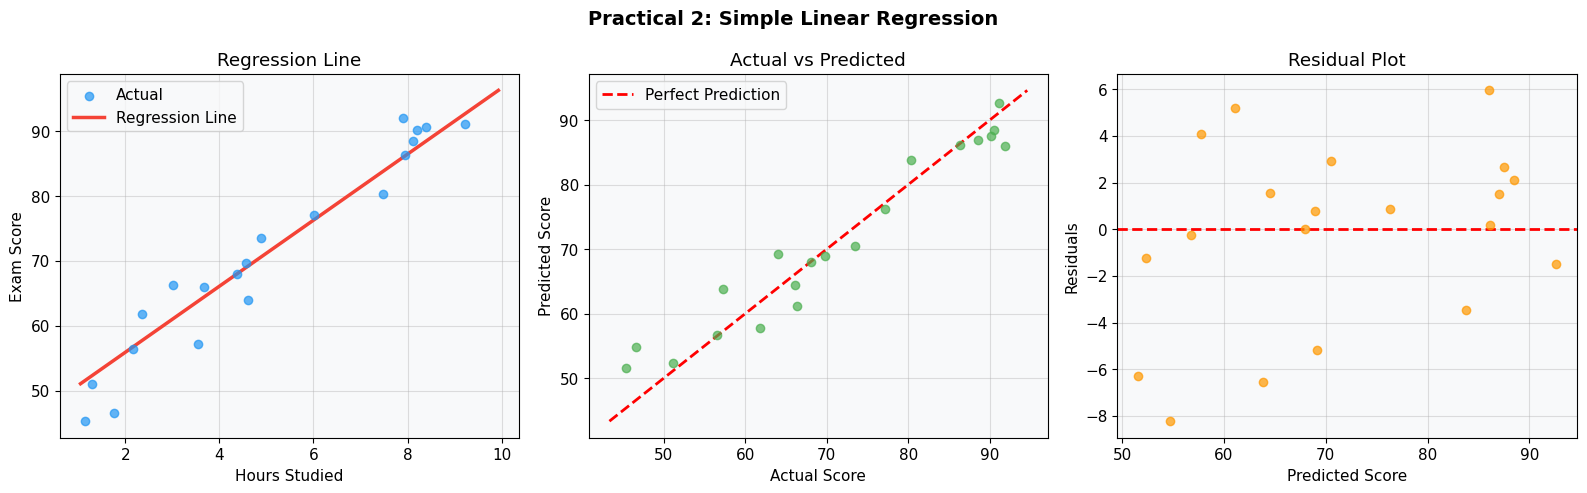

✅ Practical 2 Complete!


In [ ]:
# ── Step 6: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical 2: Simple Linear Regression', fontsize=14, fontweight='bold')

# Plot 1: Regression Line
axes[0].scatter(X2_test, y2_test, color=COLORS[0], alpha=0.7, label='Actual', zorder=3)
x_line = np.linspace(X2.min(), X2.max(), 200).reshape(-1,1)
axes[0].plot(x_line, lr2.predict(x_line), color=COLORS[1], linewidth=2.5, label='Regression Line')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Exam Score')
axes[0].set_title('Regression Line')
axes[0].legend()

# Plot 2: Actual vs Predicted
axes[1].scatter(y2_test, y2_pred, color=COLORS[2], alpha=0.7, zorder=3)
lims = [min(y2_test.min(), y2_pred.min())-2, max(y2_test.max(), y2_pred.max())+2]
axes[1].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Score')
axes[1].set_ylabel('Predicted Score')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

# Plot 3: Residuals
residuals = y2_test - y2_pred
axes[2].scatter(y2_pred, residuals, color=COLORS[3], alpha=0.7, zorder=3)
axes[2].axhline(0, color='red', linestyle='--', linewidth=2)
axes[2].set_xlabel('Predicted Score')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residual Plot')

plt.tight_layout()
plt.show()
print("✅ Practical 2 Complete!")

---
# 🔬 Practical 3: Multiple Linear Regression

In [8]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 3: MULTIPLE LINEAR REGRESSION
# Synthetic dataset: Predicting house price from multiple features
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Create Dataset ──────────────────────────────────────────
np.random.seed(42)
n = 200
area       = np.random.randint(500, 3000, n)       # sq ft
bedrooms   = np.random.randint(1, 6, n)             # count
age        = np.random.randint(0, 40, n)            # years
distance   = np.random.uniform(1, 30, n)            # km from city centre

# Price = f(area, bedrooms, age, distance) + noise
price = (200*area + 15000*bedrooms - 800*age - 5000*distance
         + np.random.normal(0, 30000, n))

df3 = pd.DataFrame({
    'Area_sqft':  area,
    'Bedrooms':   bedrooms,
    'Age_years':  age,
    'Distance_km': distance,
    'Price':      price
})

print("Dataset Shape:", df3.shape)
display(df3.head())
print("\nDataset Statistics:")
display(df3.describe())

Dataset Shape: (200, 5)


,Area_sqft,Bedrooms,Age_years,Distance_km,Price
0,1360,3,20,29.257449,152730.358929
1,1794,2,38,29.600112,174068.956058
2,1630,3,35,21.246690,217211.468233
3,1595,3,32,16.546795,257087.987020
4,2138,4,29,9.976301,388706.094680



Dataset Statistics:


,Area_sqft,Bedrooms,Age_years,Distance_km,Price
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1793.225000,2.940000,20.460000,15.066990,310192.620550
std,679.916795,1.434114,11.391101,8.387077,147406.849854
min,501.000000,1.000000,0.000000,1.421795,1247.844236
25%,1259.000000,2.000000,11.000000,7.817343,195324.936843
50%,1801.500000,3.000000,21.000000,14.668495,308766.426896
75%,2327.500000,4.000000,31.000000,22.188835,417020.725138
max,2989.000000,5.000000,39.000000,29.991813,649136.710825


In [9]:
# ── Step 2: Features & Target ───────────────────────────────────────
X3 = df3[['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_km']].values
y3 = df3['Price'].values

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

# ── Step 3: Scale Features ──────────────────────────────────────────
scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

# ── Step 4: Train Model ─────────────────────────────────────────────
lr3 = LinearRegression()
lr3.fit(X3_train_sc, y3_train)

feature_names3 = ['Area_sqft', 'Bedrooms', 'Age_years', 'Distance_km']
print("Learned Coefficients (after scaling):")
for name, coef in zip(feature_names3, lr3.coef_):
    print(f"  {name:15s}: {coef:>12,.2f}")
print(f"  Intercept      : {lr3.intercept_:>12,.2f}")

# ── Step 5: Predict & Evaluate ──────────────────────────────────────
y3_pred = lr3.predict(X3_test_sc)

mse3  = mean_squared_error(y3_test, y3_pred)
rmse3 = np.sqrt(mse3)
mae3  = mean_absolute_error(y3_test, y3_pred)
r2_3  = r2_score(y3_test, y3_pred)

print(f"\n{'='*45}")
print(f"  MULTIPLE LINEAR REGRESSION — METRICS")
print(f"{'='*45}")
print(f"  MSE  : {mse3:,.2f}")
print(f"  RMSE : {rmse3:,.2f}")
print(f"  MAE  : {mae3:,.2f}")
print(f"  R²   : {r2_3:.4f}")

# ── Step 6: k-Fold CV ───────────────────────────────────────────────
pipe3 = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
cv3   = cross_val_score(pipe3, X3, y3, cv=5, scoring='r2')
print(f"\n  5-Fold CV R² : {cv3.round(4)}")
print(f"  Mean CV R²   : {cv3.mean():.4f} ± {cv3.std():.4f}")

Learned Coefficients (after scaling):
  Area_sqft      :   137,736.50
  Bedrooms       :    23,734.64
  Age_years      :   -11,081.73
  Distance_km    :   -42,358.62
  Intercept      :   310,613.60

  MULTIPLE LINEAR REGRESSION — METRICS
  MSE  : 740,850,306.57
  RMSE : 27,218.57
  MAE  : 22,060.42
  R²   : 0.9593

  5-Fold CV R² : [0.9635 0.9623 0.9502 0.9371 0.9644]
  Mean CV R²   : 0.9555 ± 0.0105


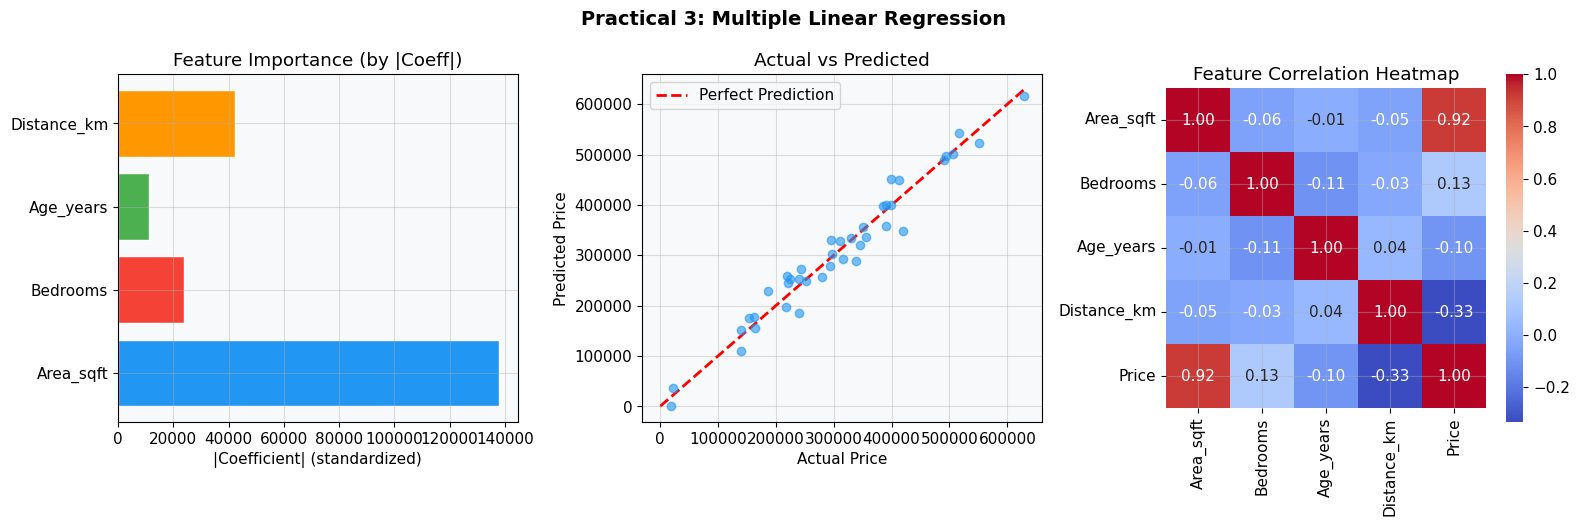

✅ Practical 3 Complete!


In [11]:
# ── Step 7: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical 3: Multiple Linear Regression', fontsize=14, fontweight='bold')

# Plot 1: Coefficient Importance
coef_abs = np.abs(lr3.coef_)
bars = axes[0].barh(feature_names3, coef_abs, color=COLORS[:4], edgecolor='white')
axes[0].set_xlabel('|Coefficient| (standardized)')
axes[0].set_title('Feature Importance (by |Coeff|)')

# Plot 2: Actual vs Predicted
axes[1].scatter(y3_test, y3_pred, color=COLORS[0], alpha=0.6, zorder=3)
lims3 = [min(y3_test.min(), y3_pred.min()), max(y3_test.max(), y3_pred.max())]
axes[1].plot(lims3, lims3, 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('Actual vs Predicted')
axes[1].legend()

# Plot 3: Correlation Heatmap
sns.heatmap(df3.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[2], cbar=True, square=True)
axes[2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()
print("✅ Practical 3 Complete!")

---
# 🔬 Practical 4: Polynomial Regression


In [12]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 4: POLYNOMIAL REGRESSION
# Dataset: Non-linear curve (e.g., speed vs stopping distance)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Create Non-Linear Dataset ──────────────────────────────
np.random.seed(42)
speed    = np.linspace(10, 100, 150)
distance = 0.02 * speed**2 + 0.5 * speed + np.random.normal(0, 10, 150)

X4 = speed.reshape(-1, 1)
y4 = distance

X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4, y4, test_size=0.2, random_state=42
)

print("Dataset: Speed → Stopping Distance")
print(f"True relationship: distance ≈ 0.02·speed² + 0.5·speed + noise")

# ── Step 2: Fit Polynomials of Different Degrees ────────────────────
degrees = [1, 2, 3, 5]
results4 = {}

print(f"\n{'Degree':>8} | {'Train R²':>10} | {'Test R²':>10} | {'Test RMSE':>12}")
print("-" * 48)

for deg in degrees:
    pipe = Pipeline([
        ('poly',  PolynomialFeatures(degree=deg, include_bias=True)),
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])
    pipe.fit(X4_train, y4_train)
    
    y4_pred_tr = pipe.predict(X4_train)
    y4_pred_te = pipe.predict(X4_test)
    
    r2_tr  = r2_score(y4_train, y4_pred_tr)
    r2_te  = r2_score(y4_test,  y4_pred_te)
    rmse_te = np.sqrt(mean_squared_error(y4_test, y4_pred_te))
    
    results4[deg] = {'pipe': pipe, 'r2_train': r2_tr, 'r2_test': r2_te, 'rmse': rmse_te}
    print(f"{deg:>8} | {r2_tr:>10.4f} | {r2_te:>10.4f} | {rmse_te:>12.4f}")

Dataset: Speed → Stopping Distance
True relationship: distance ≈ 0.02·speed² + 0.5·speed + noise

  Degree |   Train R² |    Test R² |    Test RMSE
------------------------------------------------
       1 |     0.9529 |     0.9636 |      14.5359
       2 |     0.9828 |     0.9851 |       9.3028
       3 |     0.9832 |     0.9842 |       9.5781
       5 |     0.9835 |     0.9848 |       9.3835


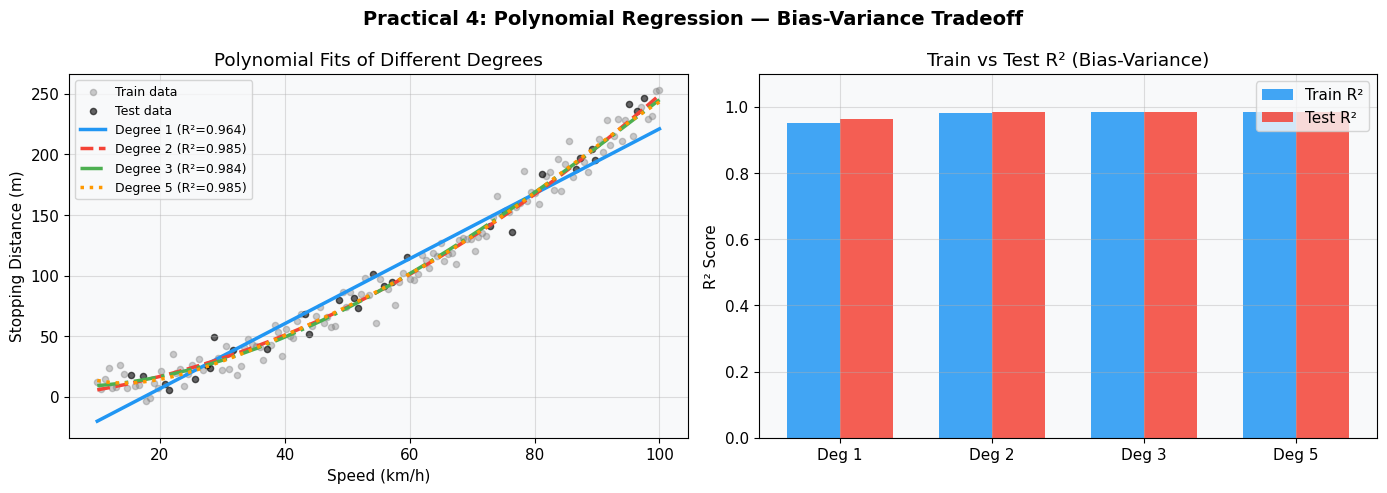

✅ Practical 4 Complete!


In [14]:
# ── Step 3: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Practical 4: Polynomial Regression — Bias-Variance Tradeoff', fontsize=14, fontweight='bold')

# Plot 1: All polynomial fits
axes[0].scatter(X4_train, y4_train, color='gray', alpha=0.4, s=20, label='Train data')
axes[0].scatter(X4_test,  y4_test,  color='black', alpha=0.6, s=20, label='Test data')

x_line4 = np.linspace(X4.min(), X4.max(), 300).reshape(-1, 1)
line_styles = ['-', '--', '-.', ':']
for i, deg in enumerate(degrees):
    y_line = results4[deg]['pipe'].predict(x_line4)
    axes[0].plot(x_line4, y_line, linewidth=2.5, linestyle=line_styles[i],
                 color=COLORS[i], label=f'Degree {deg} (R²={results4[deg]["r2_test"]:.3f})')

axes[0].set_xlabel('Speed (km/h)')
axes[0].set_ylabel('Stopping Distance (m)')
axes[0].set_title('Polynomial Fits of Different Degrees')
axes[0].legend(fontsize=9)

# Plot 2: Train vs Test R² by Degree
r2_train_vals = [results4[d]['r2_train'] for d in degrees]
r2_test_vals  = [results4[d]['r2_test']  for d in degrees]
x_deg = np.arange(len(degrees))
width = 0.35
axes[1].bar(x_deg - width/2, r2_train_vals, width, label='Train R²', color=COLORS[0], alpha=0.85)
axes[1].bar(x_deg + width/2, r2_test_vals,  width, label='Test R²',  color=COLORS[1], alpha=0.85)
axes[1].set_xticks(x_deg)
axes[1].set_xticklabels([f'Deg {d}' for d in degrees])
axes[1].set_ylabel('R² Score')
axes[1].set_title('Train vs Test R² (Bias-Variance)')
axes[1].legend()
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()
print("✅ Practical 4 Complete!")

---
# 🔬 Practical 5: Lasso and Ridge Regression


In [15]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 5: LASSO AND RIDGE REGRESSION
# Dataset: Synthetic with many features (some irrelevant)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Create Dataset (10 features, only 5 are relevant) ──────
X5, y5 = make_regression(
    n_samples=300, n_features=10, n_informative=5,
    noise=15, random_state=42
)
feature_names5 = [f'Feature_{i+1}' for i in range(10)]

X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5, y5, test_size=0.2, random_state=42
)

scaler5 = StandardScaler()
X5_train_sc = scaler5.fit_transform(X5_train)
X5_test_sc  = scaler5.transform(X5_test)

print(f"Dataset: {X5.shape[0]} samples, {X5.shape[1]} features (5 informative, 5 noise)")

# ── Step 2: Train all three models ─────────────────────────────────
models5 = {
    'Linear (No Reg)': LinearRegression(),
    'Ridge (α=1.0)':   Ridge(alpha=1.0),
    'Lasso (α=1.0)':   Lasso(alpha=1.0),
}

print(f"\n{'Model':>20} | {'Train R²':>10} | {'Test R²':>10} | {'Test RMSE':>12}")
print("-" * 60)
coefs5 = {}
for name, model in models5.items():
    model.fit(X5_train_sc, y5_train)
    y5_pred = model.predict(X5_test_sc)
    r2_tr  = r2_score(y5_train, model.predict(X5_train_sc))
    r2_te  = r2_score(y5_test, y5_pred)
    rmse   = np.sqrt(mean_squared_error(y5_test, y5_pred))
    coefs5[name] = model.coef_
    print(f"{name:>20} | {r2_tr:>10.4f} | {r2_te:>10.4f} | {rmse:>12.4f}")

Dataset: 300 samples, 10 features (5 informative, 5 noise)

               Model |   Train R² |    Test R² |    Test RMSE
------------------------------------------------------------
     Linear (No Reg) |     0.9925 |     0.9922 |      13.2874
       Ridge (α=1.0) |     0.9925 |     0.9922 |      13.2729
       Lasso (α=1.0) |     0.9923 |     0.9917 |      13.6719


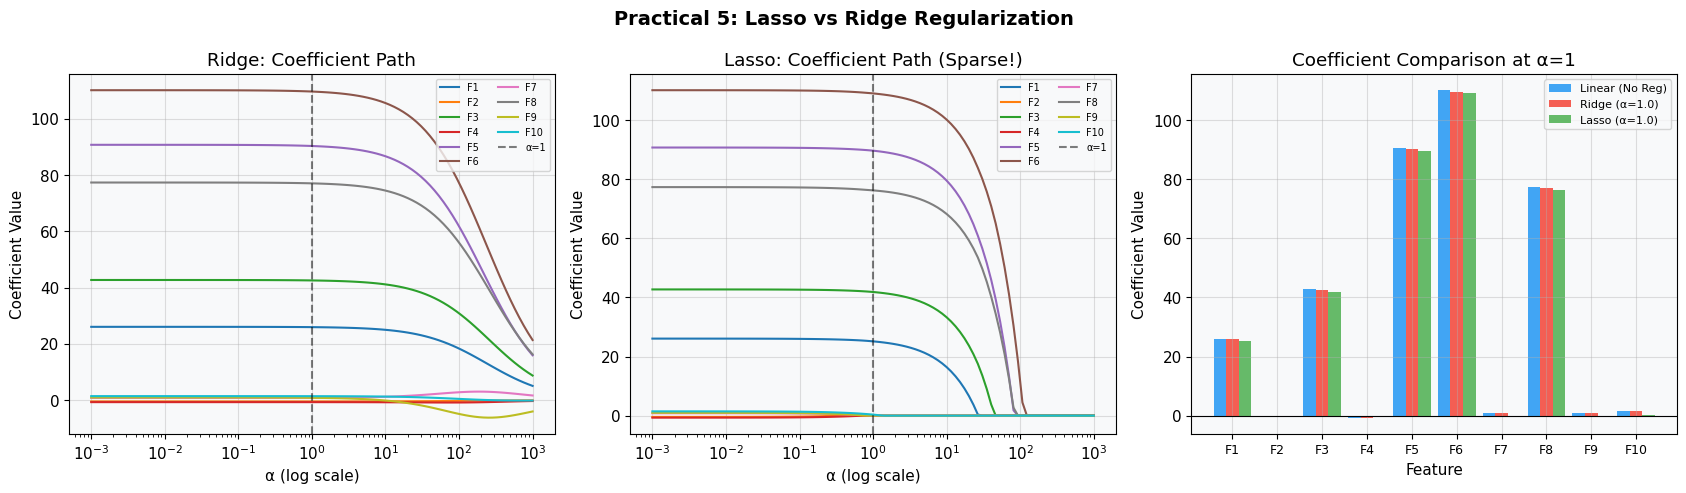

✅ Practical 5 Complete!


In [17]:
# ── Step 3: Effect of Alpha on Coefficients ─────────────────────────
alphas = np.logspace(-3, 3, 100)
ridge_coefs, lasso_coefs = [], []

for a in alphas:
    r = Ridge(alpha=a).fit(X5_train_sc, y5_train)
    l = Lasso(alpha=a, max_iter=5000).fit(X5_train_sc, y5_train)
    ridge_coefs.append(r.coef_)
    lasso_coefs.append(l.coef_)

# ── Step 4: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Practical 5: Lasso vs Ridge Regularization', fontsize=14, fontweight='bold')

# Plot 1: Ridge coefficient path
for i in range(10):
    axes[0].semilogx(alphas, [c[i] for c in ridge_coefs],
                     label=f'F{i+1}', linewidth=1.5)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='α=1')
axes[0].set_title('Ridge: Coefficient Path')
axes[0].set_xlabel('α (log scale)')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend(fontsize=7, ncol=2)

# Plot 2: Lasso coefficient path
for i in range(10):
    axes[1].semilogx(alphas, [c[i] for c in lasso_coefs],
                     label=f'F{i+1}', linewidth=1.5)
axes[1].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='α=1')
axes[1].set_title('Lasso: Coefficient Path (Sparse!)')
axes[1].set_xlabel('α (log scale)')
axes[1].set_ylabel('Coefficient Value')
axes[1].legend(fontsize=7, ncol=2)

# Plot 3: Coefficient comparison at α=1
x5_pos = np.arange(10)
width5 = 0.28
for idx, (name, coef) in enumerate(coefs5.items()):
    axes[2].bar(x5_pos + idx*width5, coef, width5,
                label=name, alpha=0.85, color=COLORS[idx])
axes[2].set_xticks(x5_pos + width5)
axes[2].set_xticklabels([f'F{i+1}' for i in range(10)], fontsize=9)
axes[2].set_title('Coefficient Comparison at α=1')
axes[2].set_xlabel('Feature')
axes[2].set_ylabel('Coefficient Value')
axes[2].legend(fontsize=8)
axes[2].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()
print("✅ Practical 5 Complete!")

---
# 🔬 Practical 6: Logistic Regression


**Classification Evaluation Metrics:**

| Metric | Formula | When to Use |
|--------|---------|-------------|
| **Accuracy** | $(TP+TN)/(Total)$ | Balanced classes |
| **Precision** | $TP/(TP+FP)$ | When false positives are costly |
| **Recall** | $TP/(TP+FN)$ | When false negatives are costly |
| **F1-Score** | $2 \cdot (P \cdot R)/(P+R)$ | Imbalanced classes |
| **AUC-ROC** | Area under ROC curve | Overall discriminative ability |

In [18]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 6: LOGISTIC REGRESSION
# Dataset: Breast Cancer Wisconsin (Binary Classification)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Load Dataset ────────────────────────────────────────────
bc = load_breast_cancer()
X6, y6 = bc.data, bc.target

print(f"Dataset: Breast Cancer Wisconsin")
print(f"Samples: {X6.shape[0]}  |  Features: {X6.shape[1]}")
print(f"Classes: {bc.target_names}  (0=Malignant, 1=Benign)")
print(f"Class distribution: Malignant={np.sum(y6==0)}, Benign={np.sum(y6==1)}")

# ── Step 2: Split & Scale ───────────────────────────────────────────
X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6, y6, test_size=0.2, random_state=42, stratify=y6
)
scaler6 = StandardScaler()
X6_train_sc = scaler6.fit_transform(X6_train)
X6_test_sc  = scaler6.transform(X6_test)

# ── Step 3: Train ────────────────────────────────────────────────────
lr6 = LogisticRegression(max_iter=1000, random_state=42)
lr6.fit(X6_train_sc, y6_train)

# ── Step 4: Predict ──────────────────────────────────────────────────
y6_pred = lr6.predict(X6_test_sc)
y6_prob = lr6.predict_proba(X6_test_sc)[:, 1]

# ── Step 5: Full Evaluation ──────────────────────────────────────────
cm6  = confusion_matrix(y6_test, y6_pred)
TP6  = cm6[1,1]; TN6 = cm6[0,0]; FP6 = cm6[0,1]; FN6 = cm6[1,0]
acc6 = accuracy_score(y6_test, y6_pred)
prec6 = precision_score(y6_test, y6_pred)
rec6  = recall_score(y6_test, y6_pred)
spec6 = TN6 / (TN6 + FP6)
f1_6  = f1_score(y6_test, y6_pred)
auc6  = roc_auc_score(y6_test, y6_prob)
err6  = 1 - acc6

print(f"\n{'='*48}")
print(f"  LOGISTIC REGRESSION — FULL METRICS")
print(f"{'='*48}")
print(f"  Confusion Matrix:  TP={TP6} | TN={TN6} | FP={FP6} | FN={FN6}")
print(f"  Accuracy     : {acc6*100:.2f}%")
print(f"  Error Rate   : {err6*100:.2f}%")
print(f"  Precision    : {prec6:.4f}")
print(f"  Recall (Sens): {rec6:.4f}")
print(f"  Specificity  : {spec6:.4f}")
print(f"  F1-Score     : {f1_6:.4f}")
print(f"  AUC-ROC      : {auc6:.4f}")

# ── 5-Fold CV ────────────────────────────────────────────────────────
pipe6 = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
cv6   = cross_val_score(pipe6, X6, y6, cv=5, scoring='accuracy')
print(f"\n  5-Fold CV Accuracy: {cv6.round(4)}")
print(f"  Mean: {cv6.mean()*100:.2f}% ± {cv6.std()*100:.2f}%")

Dataset: Breast Cancer Wisconsin
Samples: 569  |  Features: 30
Classes: ['malignant' 'benign']  (0=Malignant, 1=Benign)
Class distribution: Malignant=212, Benign=357

  LOGISTIC REGRESSION — FULL METRICS
  Confusion Matrix:  TP=71 | TN=41 | FP=1 | FN=1
  Accuracy     : 98.25%
  Error Rate   : 1.75%
  Precision    : 0.9861
  Recall (Sens): 0.9861
  Specificity  : 0.9762
  F1-Score     : 0.9861
  AUC-ROC      : 0.9954

  5-Fold CV Accuracy: [0.9825 0.9825 0.9737 0.9737 0.9912]
  Mean: 98.07% ± 0.65%


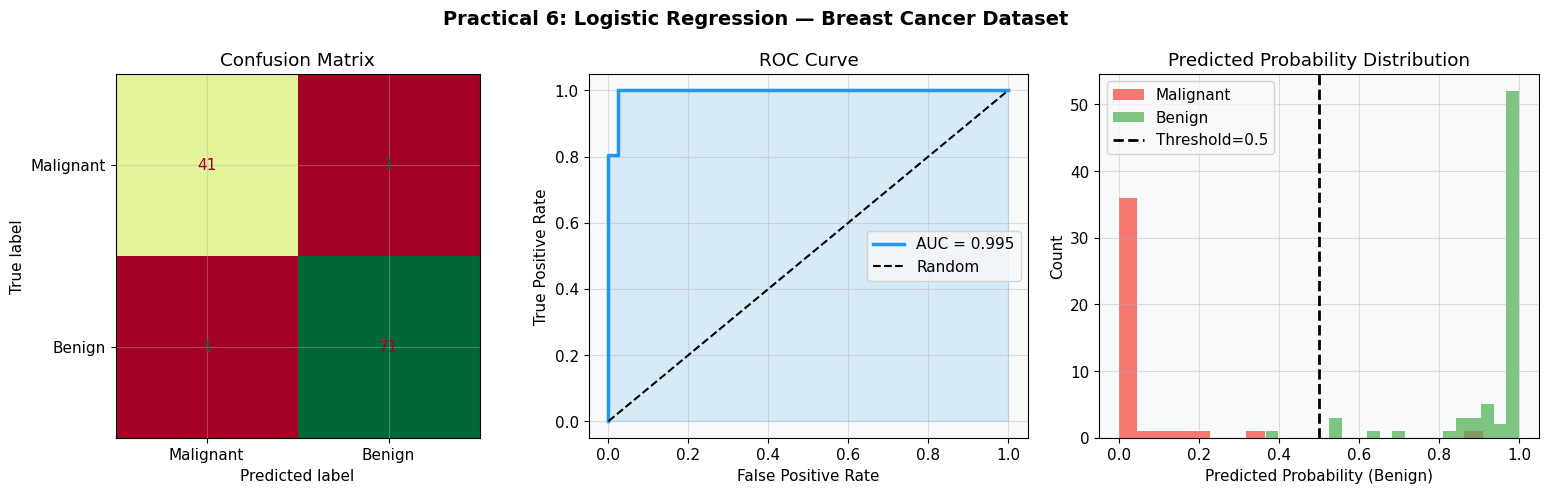

✅ Practical 6 Complete!


In [20]:
# ── Step 6: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical 6: Logistic Regression — Breast Cancer Dataset', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
ConfusionMatrixDisplay(cm6, display_labels=['Malignant', 'Benign']).plot(
    ax=axes[0], cmap='RdYlGn', colorbar=False)
axes[0].set_title('Confusion Matrix')

# Plot 2: ROC Curve
fpr, tpr, _ = roc_curve(y6_test, y6_prob)
axes[1].plot(fpr, tpr, color=COLORS[0], linewidth=2.5, label=f'AUC = {auc6:.3f}')
axes[1].plot([0,1],[0,1], 'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.15, color=COLORS[0])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# Plot 3: Predicted Probability Distribution
axes[2].hist(y6_prob[y6_test==0], bins=20, alpha=0.7, color=COLORS[1], label='Malignant')
axes[2].hist(y6_prob[y6_test==1], bins=20, alpha=0.7, color=COLORS[2], label='Benign')
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[2].set_xlabel('Predicted Probability (Benign)')
axes[2].set_ylabel('Count')
axes[2].set_title('Predicted Probability Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()
print("✅ Practical 6 Complete!")

---
# 🔬 Practical 7: Artificial Neural Network (ANN)


**Activation Functions:**
| Function | Formula | Use |
|----------|---------|------|
| ReLU | $\max(0, x)$ | Most common for hidden layers |
| Sigmoid | $1/(1+e^{-x})$ | Output for binary classification |
| Tanh | $(e^x-e^{-x})/(e^x+e^{-x})$ | Hidden layers (zero-centered) |

In [21]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 7: ARTIFICIAL NEURAL NETWORK (MLP)
# Dataset: Wine Quality (Multi-class Classification)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Load Dataset ────────────────────────────────────────────
wine = load_wine()
X7, y7 = wine.data, wine.target

print(f"Dataset: Wine Recognition")
print(f"Samples: {X7.shape[0]}  |  Features: {X7.shape[1]}  |  Classes: {len(np.unique(y7))}")
print(f"Classes: {wine.target_names}")

# ── Step 2: Split & Scale ───────────────────────────────────────────
X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7, test_size=0.2, random_state=42, stratify=y7
)
scaler7 = StandardScaler()
X7_train_sc = scaler7.fit_transform(X7_train)
X7_test_sc  = scaler7.transform(X7_test)

# ── Step 3: Train MLP with different architectures ──────────────────
architectures = {
    'Shallow (64)':          (64,),
    'Medium (128, 64)':      (128, 64),
    'Deep (256, 128, 64)':   (256, 128, 64),
}

print(f"\n{'Architecture':>25} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 52)
ann_results = {}
for name, hidden in architectures.items():
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation='relu', solver='adam',
        max_iter=500, random_state=42
    )
    mlp.fit(X7_train_sc, y7_train)
    tr_acc = mlp.score(X7_train_sc, y7_train)
    te_acc = mlp.score(X7_test_sc,  y7_test)
    ann_results[name] = mlp
    print(f"{name:>25} | {tr_acc*100:>9.2f}% | {te_acc*100:>9.2f}%")

# ── Step 4: Best model evaluation ──────────────────────────────────
best_mlp = ann_results['Deep (256, 128, 64)']
y7_pred  = best_mlp.predict(X7_test_sc)

print(f"\nBest Model — Full Classification Report:")
print(classification_report(y7_test, y7_pred, target_names=wine.target_names))

# ── 5-Fold CV ────────────────────────────────────────────────────────
pipe7 = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42))
])
cv7 = cross_val_score(pipe7, X7, y7, cv=5, scoring='accuracy')
print(f"5-Fold CV: {cv7.round(4)}")
print(f"Mean: {cv7.mean()*100:.2f}% ± {cv7.std()*100:.2f}%")

Dataset: Wine Recognition
Samples: 178  |  Features: 13  |  Classes: 3
Classes: ['class_0' 'class_1' 'class_2']

             Architecture |  Train Acc |   Test Acc
----------------------------------------------------
             Shallow (64) |    100.00% |     97.22%
         Medium (128, 64) |    100.00% |     97.22%
      Deep (256, 128, 64) |    100.00% |     94.44%

Best Model — Full Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36

5-Fold CV: [0.9722 0.9722 1.     1.     1.    ]
Mean: 98.89% ± 1.36%


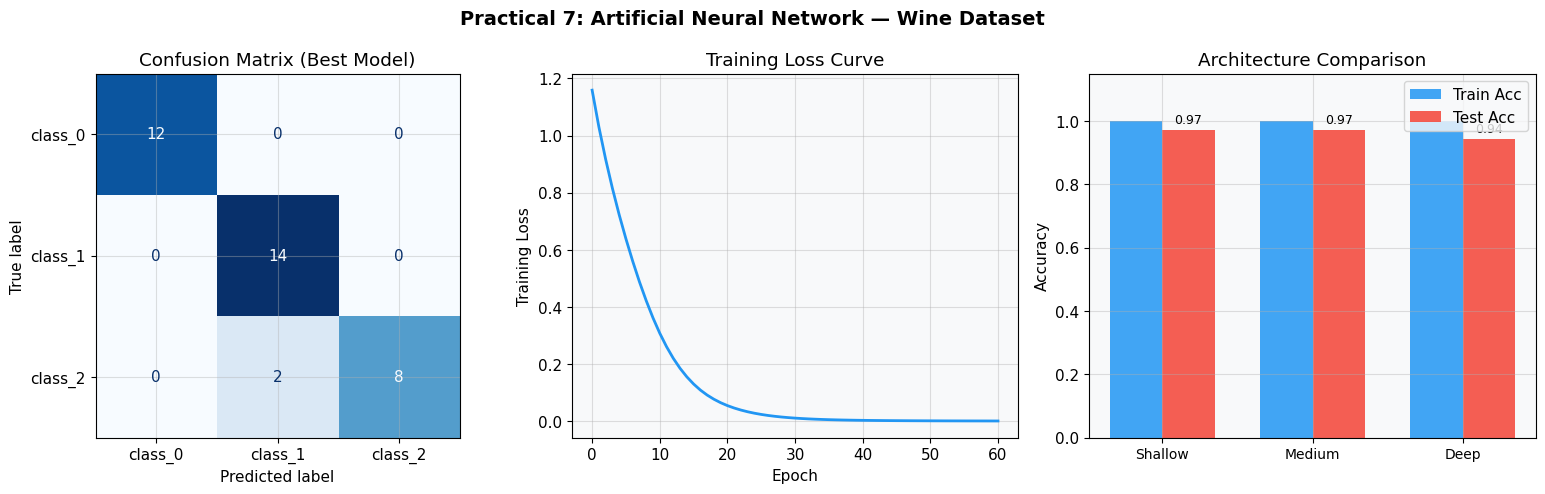

✅ Practical 7 Complete!


In [22]:
# ── Step 5: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Practical 7: Artificial Neural Network — Wine Dataset', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix
cm7 = confusion_matrix(y7_test, y7_pred)
ConfusionMatrixDisplay(cm7, display_labels=wine.target_names).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Best Model)')

# Plot 2: Loss Curve
axes[1].plot(best_mlp.loss_curve_, color=COLORS[0], linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Training Loss')
axes[1].set_title('Training Loss Curve')

# Plot 3: Architecture comparison
names7 = list(ann_results.keys())
test_accs7 = [ann_results[n].score(X7_test_sc, y7_test) for n in names7]
train_accs7 = [ann_results[n].score(X7_train_sc, y7_train) for n in names7]
x7 = np.arange(len(names7))
w7 = 0.35
axes[2].bar(x7 - w7/2, train_accs7, w7, color=COLORS[0], label='Train Acc', alpha=0.85)
axes[2].bar(x7 + w7/2, test_accs7,  w7, color=COLORS[1], label='Test Acc',  alpha=0.85)
axes[2].set_xticks(x7)
axes[2].set_xticklabels(['Shallow', 'Medium', 'Deep'], fontsize=10)
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.15)
axes[2].set_title('Architecture Comparison')
axes[2].legend()
for xi, va in enumerate(test_accs7):
    axes[2].text(xi + w7/2, va + 0.02, f'{va:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print("✅ Practical 7 Complete!")

---
# 🔬 Practical 8: K-Nearest Neighbor (K-NN) Classifier

**Distance Metrics:**

| Metric | Formula |
|--------|--------|
| **Euclidean** | $\sqrt{\sum(x_i - y_i)^2}$ |
| **Manhattan** | $\sum|x_i - y_i|$ |
| **Minkowski** | $\left(\sum|x_i - y_i|^p\right)^{1/p}$ |

**Choosing K:**
- Small K → complex boundary, overfitting
- Large K → smooth boundary, underfitting
- Use cross-validation to find optimal K
- Rule of thumb: $K = \sqrt{n}$

In [23]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 8: K-NN CLASSIFIER
# Dataset: Iris (to visualize decision boundary in 2D)
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Dataset ─────────────────────────────────────────────────
iris8 = load_iris()
X8_full, y8 = iris8.data, iris8.target
X8 = X8_full[:, :2]  # Use only 2 features for decision boundary visualization

X8_train, X8_test, y8_train, y8_test = train_test_split(
    X8, y8, test_size=0.2, random_state=42, stratify=y8
)
scaler8 = StandardScaler()
X8_train_sc = scaler8.fit_transform(X8_train)
X8_test_sc  = scaler8.transform(X8_test)

# ── Step 2: Find Optimal K using Cross-Validation ───────────────────
k_range = range(1, 26)
k_scores_cv   = []
k_scores_test = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X8_train_sc, y8_train, cv=5, scoring='accuracy')
    knn.fit(X8_train_sc, y8_train)
    k_scores_cv.append(cv_score.mean())
    k_scores_test.append(knn.score(X8_test_sc, y8_test))

best_k = k_range.start + np.argmax(k_scores_cv)
print(f"Optimal K (by CV): {best_k}  |  CV Accuracy: {max(k_scores_cv)*100:.2f}%")

# ── Step 3: Train Final Model ────────────────────────────────────────
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X8_train_sc, y8_train)
y8_pred = knn_best.predict(X8_test_sc)

acc8  = accuracy_score(y8_test, y8_pred)
cm8   = confusion_matrix(y8_test, y8_pred)

print(f"\n{'='*50}")
print(f"  K-NN (K={best_k}) — EVALUATION")
print(f"{'='*50}")
print(f"  Accuracy : {acc8*100:.2f}%")
print(f"  Error    : {(1-acc8)*100:.2f}%")
print(classification_report(y8_test, y8_pred, target_names=iris8.target_names))

Optimal K (by CV): 6  |  CV Accuracy: 82.50%

  K-NN (K=6) — EVALUATION
  Accuracy : 66.67%
  Error    : 33.33%
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.50      0.80      0.62        10
   virginica       0.50      0.20      0.29        10

    accuracy                           0.67        30
   macro avg       0.67      0.67      0.63        30
weighted avg       0.67      0.67      0.63        30



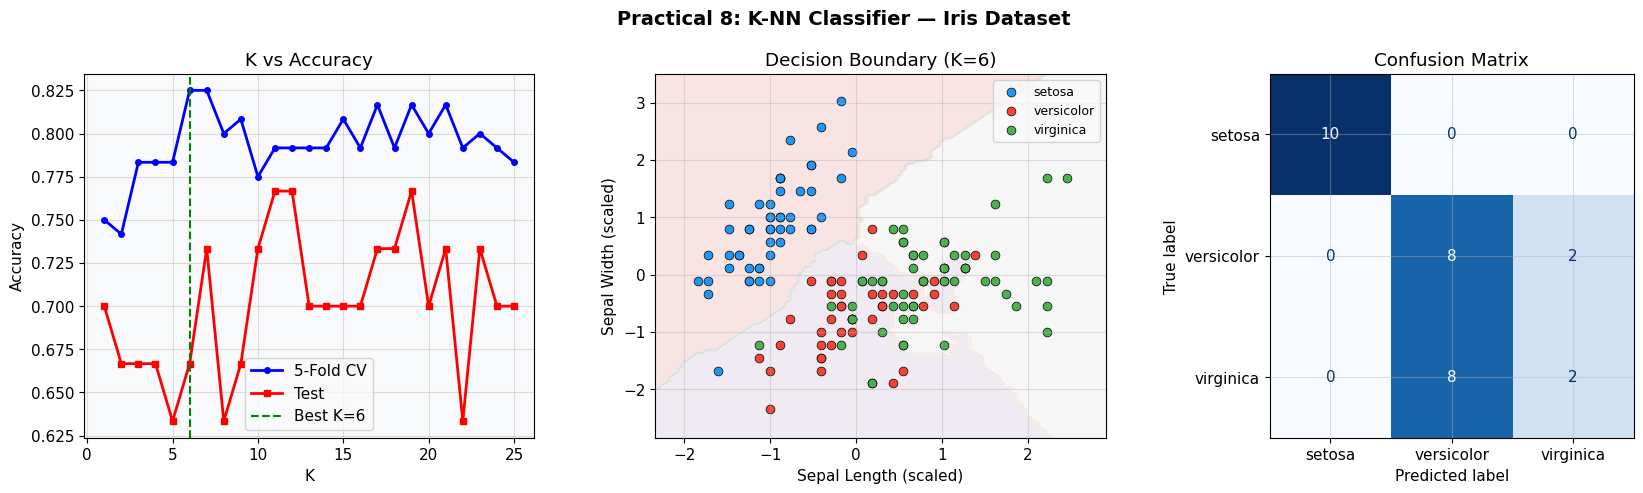

✅ Practical 8 Complete!


In [25]:
# ── Step 4: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Practical 8: K-NN Classifier — Iris Dataset', fontsize=14, fontweight='bold')

# Plot 1: K vs Accuracy
axes[0].plot(k_range, k_scores_cv,   'b-o', markersize=4, label='5-Fold CV', linewidth=2)
axes[0].plot(k_range, k_scores_test, 'r-s', markersize=4, label='Test',      linewidth=2)
axes[0].axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('K vs Accuracy')
axes[0].legend()

# Plot 2: Decision Boundary
h = 0.05
X8_sc_all = scaler8.transform(X8)
x_min, x_max = X8_sc_all[:, 0].min() - 0.5, X8_sc_all[:, 0].max() + 0.5
y_min, y_max = X8_sc_all[:, 1].min() - 0.5, X8_sc_all[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn_best.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
for cls, color, name in zip([0,1,2], COLORS[:3], iris8.target_names):
    mask = y8 == cls
    axes[1].scatter(X8_sc_all[mask, 0], X8_sc_all[mask, 1],
                    c=color, label=name, edgecolors='k', linewidths=0.5, s=40)
axes[1].set_xlabel('Sepal Length (scaled)')
axes[1].set_ylabel('Sepal Width (scaled)')
axes[1].set_title(f'Decision Boundary (K={best_k})')
axes[1].legend(fontsize=9)

# Plot 3: Confusion Matrix
ConfusionMatrixDisplay(cm8, display_labels=iris8.target_names).plot(
    ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Confusion Matrix')

plt.tight_layout()
plt.show()
print("✅ Practical 8 Complete!")

---
# 🔬 Practical 9: Decision Tree Classification


**Key Hyperparameters:**
| Parameter | Effect |
|-----------|-------|
| `max_depth` | Controls tree complexity; prevents overfitting |
| `min_samples_split` | Min samples needed to split a node |
| `min_samples_leaf` | Min samples in a leaf node |
| `criterion` | 'gini' or 'entropy' |

In [26]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 9: DECISION TREE CLASSIFICATION
# Dataset: Breast Cancer Wisconsin
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Dataset ─────────────────────────────────────────────────
bc9 = load_breast_cancer()
X9, y9 = bc9.data, bc9.target

X9_train, X9_test, y9_train, y9_test = train_test_split(
    X9, y9, test_size=0.2, random_state=42, stratify=y9
)

# ── Step 2: Study Effect of Tree Depth ─────────────────────────────
depths = [1, 2, 3, 5, 7, 10, None]
print(f"{'Depth':>8} | {'Train Acc':>10} | {'Test Acc':>10}")
print("-" * 35)
depth_results = {}

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X9_train, y9_train)
    tr = dt.score(X9_train, y9_train)
    te = dt.score(X9_test,  y9_test)
    depth_results[d] = (tr, te, dt)
    print(f"{str(d):>8} | {tr*100:>9.2f}% | {te*100:>9.2f}%")

# ── Step 3: Best Model (max_depth=5) ────────────────────────────────
best_dt = depth_results[5][2]
y9_pred = best_dt.predict(X9_test)
cm9     = confusion_matrix(y9_test, y9_pred)

print(f"\n{'='*50}")
print(f"  DECISION TREE (depth=5) — EVALUATION")
print(f"{'='*50}")
print(f"  Accuracy : {accuracy_score(y9_test, y9_pred)*100:.2f}%")
print(classification_report(y9_test, y9_pred, target_names=bc9.target_names))

# ── 5-Fold CV ────────────────────────────────────────────────────────
cv9 = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                      X9, y9, cv=5, scoring='accuracy')
print(f"5-Fold CV: {cv9.round(4)}")
print(f"Mean: {cv9.mean()*100:.2f}% ± {cv9.std()*100:.2f}%")

   Depth |  Train Acc |   Test Acc
-----------------------------------
       1 |     92.31% |     92.11%
       2 |     95.82% |     89.47%
       3 |     97.58% |     93.86%
       5 |     99.34% |     92.11%
       7 |    100.00% |     91.23%
      10 |    100.00% |     91.23%
    None |    100.00% |     91.23%

  DECISION TREE (depth=5) — EVALUATION
  Accuracy : 92.11%
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114

5-Fold CV: [0.8947 0.9123 0.9298 0.9474 0.9115]
Mean: 91.91% ± 1.80%


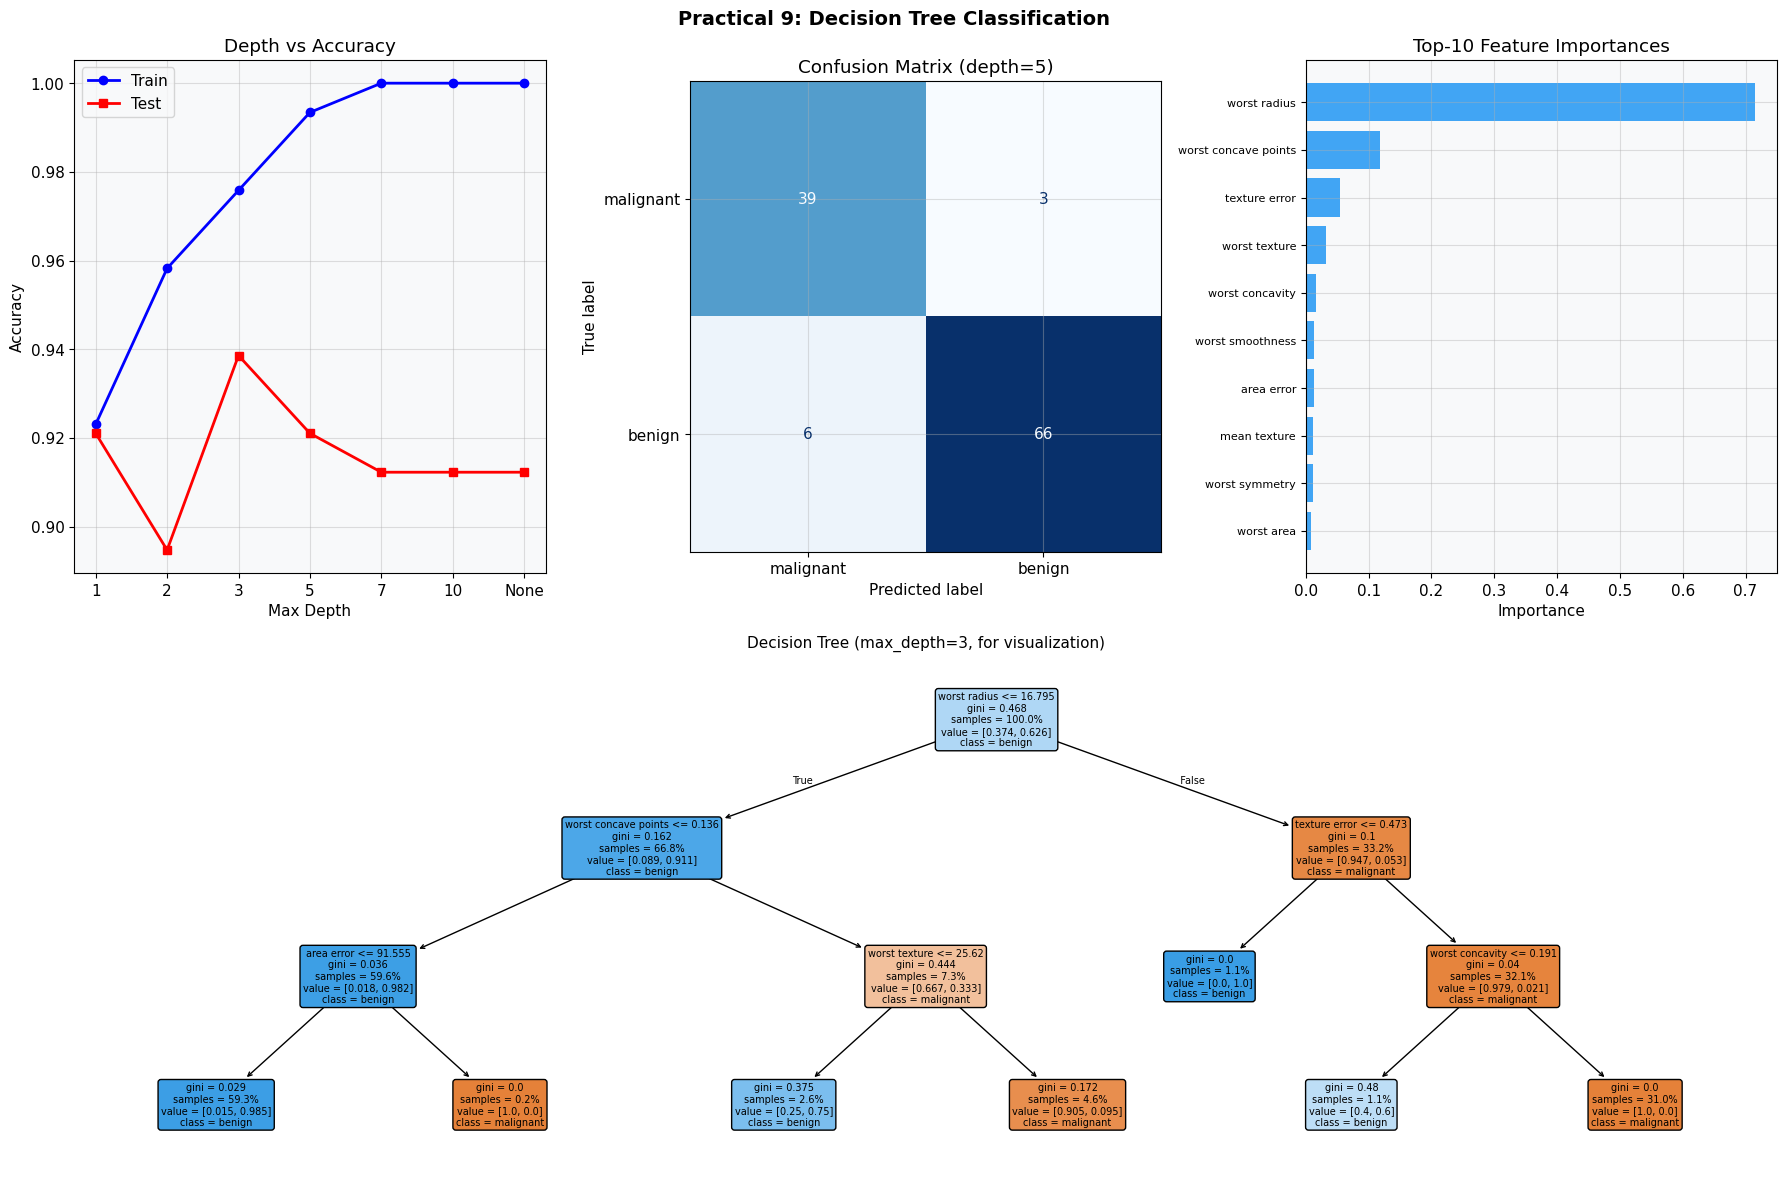

✅ Practical 9 Complete!


In [27]:
# ── Step 4: Visualization ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Practical 9: Decision Tree Classification', fontsize=14, fontweight='bold')

gs = gridspec.GridSpec(2, 3, figure=fig)

# Plot 1: Depth vs Accuracy
ax1 = fig.add_subplot(gs[0, 0])
depth_labels = [str(d) for d in depths]
train_accs9  = [depth_results[d][0] for d in depths]
test_accs9   = [depth_results[d][1] for d in depths]
ax1.plot(depth_labels, train_accs9, 'b-o', label='Train', linewidth=2)
ax1.plot(depth_labels, test_accs9,  'r-s', label='Test',  linewidth=2)
ax1.set_xlabel('Max Depth')
ax1.set_ylabel('Accuracy')
ax1.set_title('Depth vs Accuracy')
ax1.legend()

# Plot 2: Confusion Matrix
ax2 = fig.add_subplot(gs[0, 1])
ConfusionMatrixDisplay(cm9, display_labels=bc9.target_names).plot(ax=ax2, cmap='Blues', colorbar=False)
ax2.set_title('Confusion Matrix (depth=5)')

# Plot 3: Feature Importance
ax3 = fig.add_subplot(gs[0, 2])
importances = best_dt.feature_importances_
top10_idx   = np.argsort(importances)[-10:]
ax3.barh(range(10), importances[top10_idx], color=COLORS[0], alpha=0.85)
ax3.set_yticks(range(10))
ax3.set_yticklabels([bc9.feature_names[i] for i in top10_idx], fontsize=8)
ax3.set_title('Top-10 Feature Importances')
ax3.set_xlabel('Importance')

# Plot 4: Decision Tree Visualization (depth=3 for readability)
ax4 = fig.add_subplot(gs[1, :])
dt_vis = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_vis.fit(X9_train, y9_train)
plot_tree(dt_vis, feature_names=bc9.feature_names, class_names=bc9.target_names,
          filled=True, rounded=True, fontsize=7, ax=ax4, impurity=True, proportion=True)
ax4.set_title('Decision Tree (max_depth=3, for visualization)', fontsize=11)

plt.tight_layout()
plt.show()
print("✅ Practical 9 Complete!")

---
# 🔬 Practical 10: SVM Classification


**Kernel Trick:** For non-linear data, map features to higher dimensions:

| Kernel | Formula | Use Case |
|--------|---------|----------|
| **Linear** | $x^Tx'$ | Linearly separable data |
| **RBF (Gaussian)** | $e^{-\gamma\|x-x'\|^2}$ | Non-linear, most common |
| **Polynomial** | $(x^Tx' + r)^d$ | Image classification |

**C** controls bias-variance: small C → wider margin (more errors allowed), large C → narrower margin (fewer errors)

In [28]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 10: SVM CLASSIFICATION
# Dataset: Breast Cancer + Moons (for kernel visualization)
# ═══════════════════════════════════════════════════════════════════

# ── Part A: SVM on Real Dataset (Breast Cancer) ─────────────────────
bc10 = load_breast_cancer()
X10, y10 = bc10.data, bc10.target

X10_train, X10_test, y10_train, y10_test = train_test_split(
    X10, y10, test_size=0.2, random_state=42, stratify=y10
)
scaler10 = StandardScaler()
X10_train_sc = scaler10.fit_transform(X10_train)
X10_test_sc  = scaler10.transform(X10_test)

# ── Different Kernels ────────────────────────────────────────────────
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
print(f"{'Kernel':>10} | {'Train Acc':>10} | {'Test Acc':>10} | {'F1':>8}")
print("-" * 48)
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=42, probability=True)
    svm.fit(X10_train_sc, y10_train)
    y10_pred = svm.predict(X10_test_sc)
    tr  = svm.score(X10_train_sc, y10_train)
    te  = accuracy_score(y10_test, y10_pred)
    f1  = f1_score(y10_test, y10_pred)
    svm_results[kernel] = {'model': svm, 'acc': te, 'f1': f1}
    print(f"{kernel:>10} | {tr*100:>9.2f}% | {te*100:>9.2f}% | {f1:>8.4f}")

# Best model: RBF
best_svm = svm_results['rbf']['model']
y10_pred_best = best_svm.predict(X10_test_sc)
cm10 = confusion_matrix(y10_test, y10_pred_best)

TP10 = cm10[1,1]; TN10 = cm10[0,0]; FP10 = cm10[0,1]; FN10 = cm10[1,0]
spec10 = TN10/(TN10+FP10)

print(f"\n{'='*50}")
print(f"  SVM (RBF Kernel) — FULL METRICS")
print(f"{'='*50}")
print(f"  TP={TP10} | TN={TN10} | FP={FP10} | FN={FN10}")
print(f"  Accuracy    : {accuracy_score(y10_test, y10_pred_best)*100:.2f}%")
print(f"  Recall      : {recall_score(y10_test, y10_pred_best):.4f}")
print(f"  Specificity : {spec10:.4f}")
print(f"  F1-Score    : {f1_score(y10_test, y10_pred_best):.4f}")

# ── 5-Fold CV ────────────────────────────────────────────────────────
pipe10 = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', C=1.0))])
cv10   = cross_val_score(pipe10, X10, y10, cv=5, scoring='accuracy')
print(f"\n5-Fold CV: {cv10.round(4)}  Mean: {cv10.mean()*100:.2f}%")

    Kernel |  Train Acc |   Test Acc |       F1
------------------------------------------------
    linear |     99.12% |     97.37% |   0.9790
       rbf |     98.24% |     98.25% |   0.9861
      poly |     91.65% |     91.23% |   0.9351
   sigmoid |     95.60% |     92.98% |   0.9437

  SVM (RBF Kernel) — FULL METRICS
  TP=71 | TN=41 | FP=1 | FN=1
  Accuracy    : 98.25%
  Recall      : 0.9861
  Specificity : 0.9762
  F1-Score    : 0.9861

5-Fold CV: [0.9737 0.9561 1.     0.9649 0.9735]  Mean: 97.36%


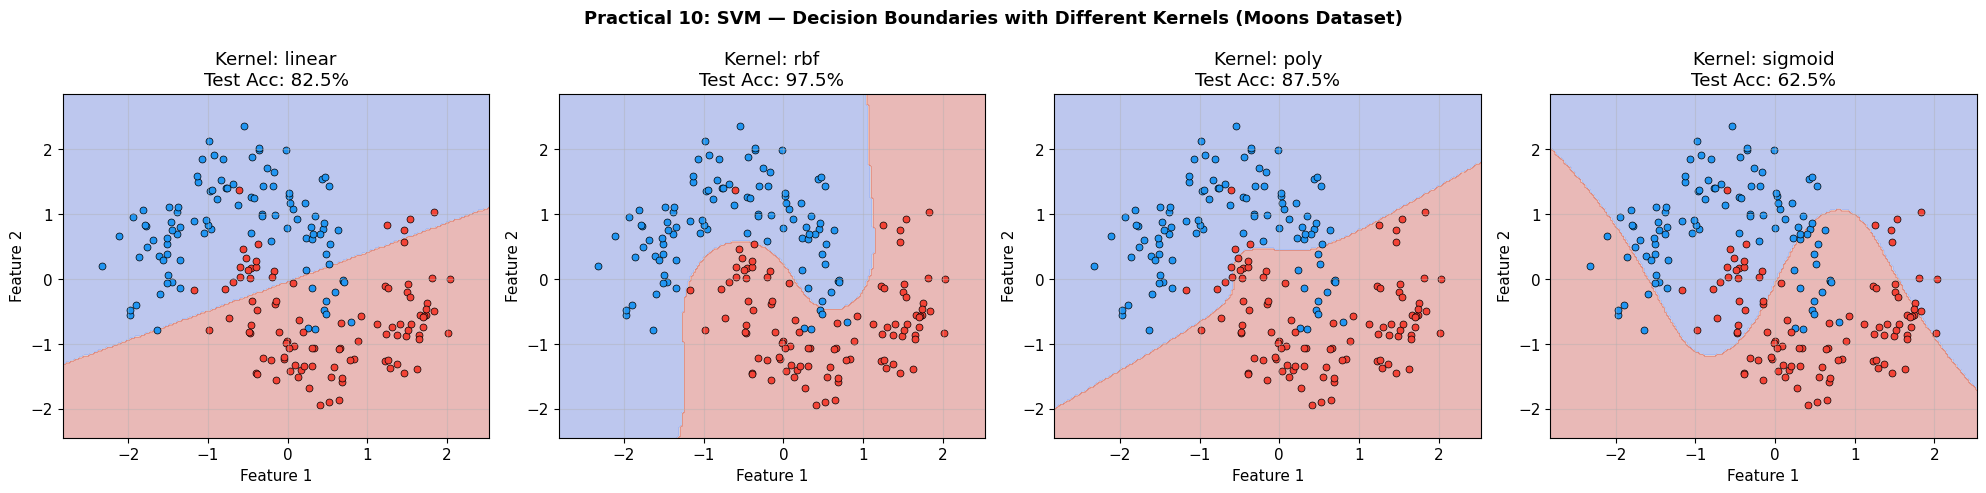

✅ Practical 10 Complete!


In [29]:
# ── Part B: Kernel Visualization on 2D Moons Dataset ────────────────
X_m, y_m = make_moons(n_samples=200, noise=0.2, random_state=42)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_m, y_m, test_size=0.2, random_state=42)
sc_m = StandardScaler()
Xm_tr_sc = sc_m.fit_transform(Xm_tr)
Xm_te_sc = sc_m.transform(Xm_te)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Practical 10: SVM — Decision Boundaries with Different Kernels (Moons Dataset)',
             fontsize=13, fontweight='bold')

Xm_sc_all = sc_m.transform(X_m)
xx_m, yy_m = np.meshgrid(
    np.linspace(Xm_sc_all[:,0].min()-0.5, Xm_sc_all[:,0].max()+0.5, 200),
    np.linspace(Xm_sc_all[:,1].min()-0.5, Xm_sc_all[:,1].max()+0.5, 200)
)

for ax, kernel in zip(axes, kernels):
    svm_m = SVC(kernel=kernel, C=2.0, gamma='scale', random_state=42)
    svm_m.fit(Xm_tr_sc, ym_tr)
    Z_m = svm_m.predict(np.c_[xx_m.ravel(), yy_m.ravel()]).reshape(xx_m.shape)
    te_acc_m = svm_m.score(Xm_te_sc, ym_te)
    
    ax.contourf(xx_m, yy_m, Z_m, alpha=0.35, cmap='coolwarm')
    ax.scatter(Xm_sc_all[y_m==0,0], Xm_sc_all[y_m==0,1], c=COLORS[0], s=25, edgecolors='k', lw=0.5)
    ax.scatter(Xm_sc_all[y_m==1,0], Xm_sc_all[y_m==1,1], c=COLORS[1], s=25, edgecolors='k', lw=0.5)
    ax.set_title(f'Kernel: {kernel}\nTest Acc: {te_acc_m*100:.1f}%')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()
print("✅ Practical 10 Complete!")

---
# 🔬 Practical 11: K-Means Clustering


In [30]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 11: K-MEANS CLUSTERING
# Dataset: Iris (ground truth available to compare)
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import silhouette_score, adjusted_rand_score

# ── Step 1: Dataset ─────────────────────────────────────────────────
iris11 = load_iris()
X11, y11 = iris11.data, iris11.target

scaler11 = StandardScaler()
X11_sc   = scaler11.fit_transform(X11)

print("Dataset: Iris (used without labels — unsupervised)")
print(f"Samples: {X11.shape[0]}  |  Features: {X11.shape[1]}")

# ── Step 2: Elbow Method ─────────────────────────────────────────────
wcss   = []
silhouettes = []
k_range11 = range(2, 11)

for k in k_range11:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X11_sc)
    wcss.append(km.inertia_)
    sil = silhouette_score(X11_sc, km.labels_)
    silhouettes.append(sil)

print(f"\n{'K':>4} | {'WCSS':>12} | {'Silhouette':>12}")
print("-" * 34)
for k, w, s in zip(k_range11, wcss, silhouettes):
    print(f"{k:>4} | {w:>12.2f} | {s:>12.4f}")

# ── Step 3: Best Model (K=3) ─────────────────────────────────────────
best_km = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
best_km.fit(X11_sc)
labels11 = best_km.labels_

ari = adjusted_rand_score(y11, labels11)
sil_best = silhouette_score(X11_sc, labels11)

print(f"\n{'='*45}")
print(f"  K-MEANS (K=3) — METRICS")
print(f"{'='*45}")
print(f"  WCSS (Inertia)      : {best_km.inertia_:.2f}")
print(f"  Silhouette Score    : {sil_best:.4f}  (higher is better, max=1)")
print(f"  Adjusted Rand Index : {ari:.4f}  (1.0 = perfect match with true labels)")

Dataset: Iris (used without labels — unsupervised)
Samples: 150  |  Features: 4

   K |         WCSS |   Silhouette
----------------------------------
   2 |       222.36 |       0.5818
   3 |       139.82 |       0.4599
   4 |       114.09 |       0.3869
   5 |        90.93 |       0.3459
   6 |        81.54 |       0.3171
   7 |        72.63 |       0.3202
   8 |        62.54 |       0.3387
   9 |        55.12 |       0.3424
  10 |        47.39 |       0.3518

  K-MEANS (K=3) — METRICS
  WCSS (Inertia)      : 139.82
  Silhouette Score    : 0.4599  (higher is better, max=1)
  Adjusted Rand Index : 0.6201  (1.0 = perfect match with true labels)


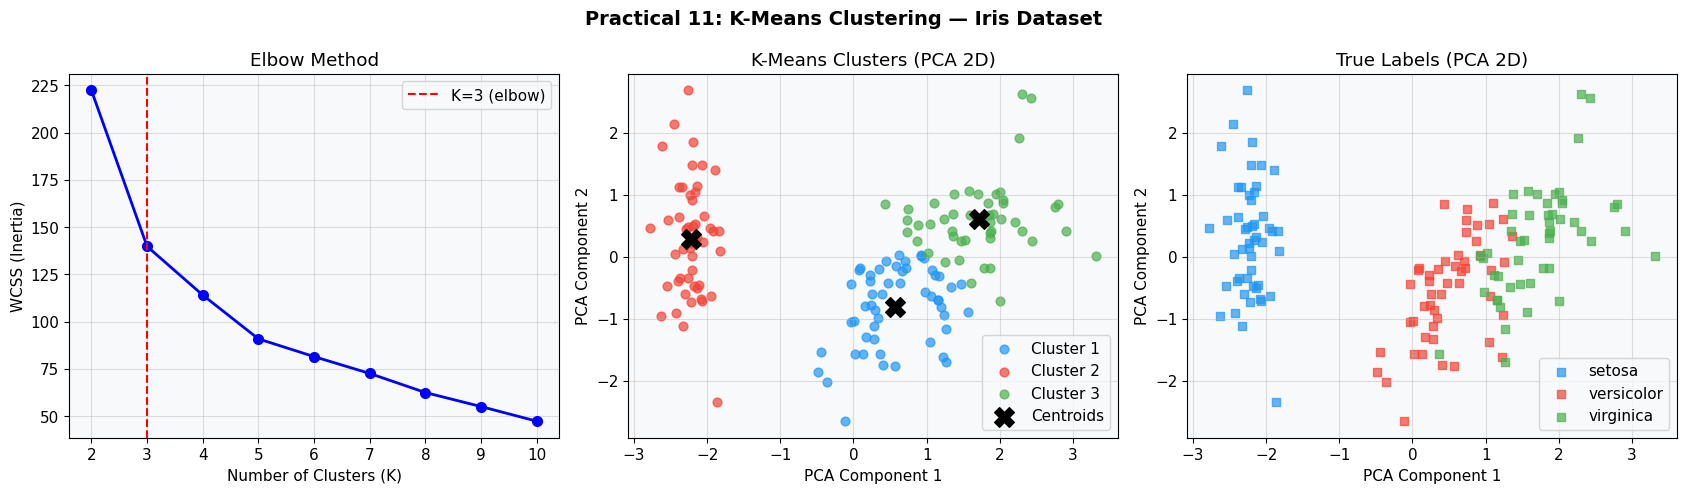

✅ Practical 11 Complete!


In [31]:
# ── Step 4: Visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Practical 11: K-Means Clustering — Iris Dataset', fontsize=14, fontweight='bold')

# Plot 1: Elbow Method
ax1 = axes[0]
ax1.plot(k_range11, wcss, 'bo-', linewidth=2, markersize=7)
ax1.axvline(3, color='red', linestyle='--', label='K=3 (elbow)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Elbow Method')
ax1.legend()

# Plot 2: Clusters (First 2 PCA components)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X11_pca = pca.fit_transform(X11_sc)
centroids_pca = pca.transform(best_km.cluster_centers_)

ax2 = axes[1]
for c in range(3):
    mask = labels11 == c
    ax2.scatter(X11_pca[mask, 0], X11_pca[mask, 1],
                color=COLORS[c], alpha=0.7, s=40, label=f'Cluster {c+1}')
ax2.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            color='black', marker='X', s=200, zorder=5, label='Centroids')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.set_title('K-Means Clusters (PCA 2D)')
ax2.legend()

# Plot 3: True Labels vs Clusters side by side
ax3 = axes[2]
for cls, name in enumerate(iris11.target_names):
    mask = y11 == cls
    ax3.scatter(X11_pca[mask, 0], X11_pca[mask, 1],
                color=COLORS[cls], alpha=0.7, s=40, marker='s', label=name)
ax3.set_xlabel('PCA Component 1')
ax3.set_ylabel('PCA Component 2')
ax3.set_title('True Labels (PCA 2D)')
ax3.legend()

plt.tight_layout()
plt.show()
print("✅ Practical 11 Complete!")

---
# 🔬 Practical 12: Hierarchical Clustering

## 📖 Theory

**Hierarchical Clustering** builds a **tree of clusters (dendrogram)** without requiring you to specify K in advance.

**Two approaches:**

| Approach | Description |
|----------|------------|
| **Agglomerative (bottom-up)** | Start with each point as its own cluster; merge the closest two clusters iteratively |
| **Divisive (top-down)** | Start with all points in one cluster; recursively split |

**Linkage Criteria** (how to measure distance between clusters):

| Linkage | Distance Measure | Effect |
|---------|-----------------|-------|
| **Single** | Min distance between any two points | Tends to form chains |
| **Complete** | Max distance between any two points | Compact, equal-size clusters |
| **Average** | Mean distance between all pairs | Compromise |
| **Ward** | Minimizes within-cluster variance | Most common, best results |

**Reading the Dendrogram:** Cut the tree at a height to get the desired number of clusters.

In [32]:
# ═══════════════════════════════════════════════════════════════════
# PRACTICAL 12: HIERARCHICAL CLUSTERING
# Dataset: Iris
# ═══════════════════════════════════════════════════════════════════

from sklearn.metrics import silhouette_score, adjusted_rand_score

# ── Step 1: Dataset ─────────────────────────────────────────────────
iris12 = load_iris()
X12, y12 = iris12.data, iris12.target
scaler12 = StandardScaler()
X12_sc   = scaler12.fit_transform(X12)

print("Dataset: Iris")
print(f"Samples: {X12.shape[0]}  |  Features: {X12.shape[1]}")

# ── Step 2: Compare Linkage Methods ─────────────────────────────────
linkage_methods = ['ward', 'complete', 'average', 'single']

print(f"\n{'Linkage':>12} | {'Silhouette':>12} | {'ARI':>10}")
print("-" * 40)
hc_results = {}

for method in linkage_methods:
    hc = AgglomerativeClustering(n_clusters=3, linkage=method)
    hc_labels = hc.fit_predict(X12_sc)
    sil = silhouette_score(X12_sc, hc_labels)
    ari = adjusted_rand_score(y12, hc_labels)
    hc_results[method] = {'labels': hc_labels, 'sil': sil, 'ari': ari}
    print(f"{method:>12} | {sil:>12.4f} | {ari:>10.4f}")

best_method = 'ward'
print(f"\nBest method: {best_method}")
print(f"Silhouette : {hc_results[best_method]['sil']:.4f}")
print(f"ARI        : {hc_results[best_method]['ari']:.4f}")

Dataset: Iris
Samples: 150  |  Features: 4

     Linkage |   Silhouette |        ARI
----------------------------------------
        ward |       0.4467 |     0.6153
    complete |       0.4496 |     0.5726
     average |       0.4803 |     0.5621
      single |       0.5046 |     0.5584

Best method: ward
Silhouette : 0.4467
ARI        : 0.6153


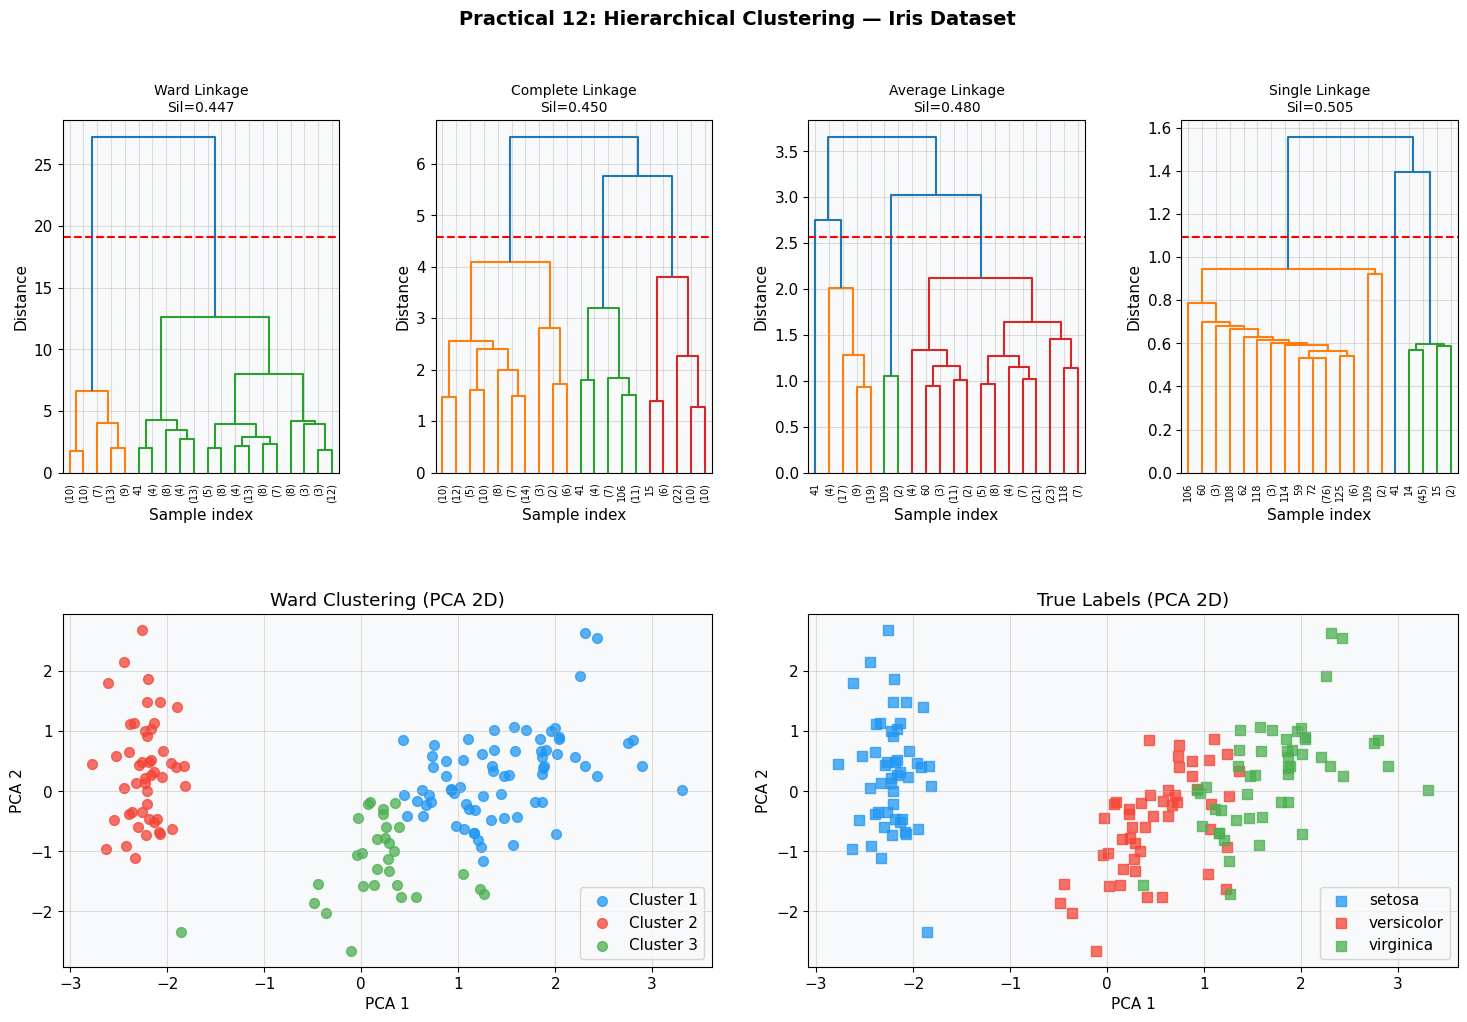

✅ Practical 12 Complete!


In [33]:
# ── Step 3: Visualization ────────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Practical 12: Hierarchical Clustering — Iris Dataset', fontsize=14, fontweight='bold')
gs12 = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1-4: Dendrograms for all linkage methods
for idx, method in enumerate(linkage_methods):
    ax = fig.add_subplot(gs12[0, idx])
    Z = linkage(X12_sc, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
               color_threshold=0.7*max(Z[:,2]),
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=7)
    ax.axhline(y=0.7*max(Z[:,2]), color='red', linestyle='--', linewidth=1.5, label='Cut')
    sil_val = hc_results[method]['sil']
    ax.set_title(f'{method.capitalize()} Linkage\nSil={sil_val:.3f}', fontsize=10)
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Distance')

# PCA for 2D cluster plots
from sklearn.decomposition import PCA
pca12 = PCA(n_components=2)
X12_pca = pca12.fit_transform(X12_sc)

# Plot 5: Ward Clustering Result
ax5 = fig.add_subplot(gs12[1, :2])
ward_labels = hc_results['ward']['labels']
for c in range(3):
    mask = ward_labels == c
    ax5.scatter(X12_pca[mask,0], X12_pca[mask,1],
                color=COLORS[c], alpha=0.75, s=50, label=f'Cluster {c+1}')
ax5.set_title('Ward Clustering (PCA 2D)')
ax5.set_xlabel('PCA 1')
ax5.set_ylabel('PCA 2')
ax5.legend()

# Plot 6: True Labels
ax6 = fig.add_subplot(gs12[1, 2:])
for cls, name in enumerate(iris12.target_names):
    mask = y12 == cls
    ax6.scatter(X12_pca[mask,0], X12_pca[mask,1],
                color=COLORS[cls], alpha=0.75, s=50, marker='s', label=name)
ax6.set_title('True Labels (PCA 2D)')
ax6.set_xlabel('PCA 1')
ax6.set_ylabel('PCA 2')
ax6.legend()

plt.show()
print("✅ Practical 12 Complete!")